# Métodos Tabulares

Este notebook presenta un estudio comparativo de métodos tabulares de aprendizaje por refuerzo aplicados al entorno `Taxi-v3`. El objetivo es analizar, bajo un mismo protocolo experimental, las diferencias en dinámica de aprendizaje, desempeño final y estabilidad entre enfoques basados en Monte Carlo y en diferencias temporales.

En particular, se evalúan cuatro algoritmos:
- Monte Carlo *on-policy* (every-visit)
- Monte Carlo *off-policy* con *Weighted Importance Sampling*
- SARSA tabular
- Q-Learning tabular

La comparación se realiza en condiciones homogéneas (mismas semillas, misma planificación de exploración `epsilon`, misma evaluación greedy y mismo criterio de éxito), con el fin de garantizar una interpretación metodológicamente consistente de los resultados.

A lo largo del notebook se documenta, para cada método, qué problema de estimación resuelve, cómo se implementa en este trabajo y qué evidencia cuantitativa respalda su comportamiento en `Taxi-v3`.

## Descripción del Entorno Taxi-v3

`Taxi-v3` es un entorno discreto con:

- `500` estados posibles
- `6` acciones discretas
- recompensa `-1` por paso
- recompensa `+20` cuando el taxi deja correctamente al pasajero
- penalización `-10` en acciones ilegales

La tarea real del agente no es solo llegar al objetivo alguna vez, sino aprender una política eficiente. Por eso en este notebook se van a separar dos cosas:

- El comportamiento durante el entrenamiento
- La calidad de la política greedy aprendida

Esa separación es especialmente importante en Monte Carlo off-policy, porque la política de comportamiento y la política objetivo no son la misma.


## Protocolo experimental

Las condiciones usadas para la validación de los algoritmos son:

- Entorno: `Taxi-v3`
- Semillas: [123, 231, 777, 2024, 31415]
- Episodios de entrenamiento por semilla: `10000`
- Factor de descuento: `gamma = 0.99`
- Exploración: `epsilon` desde `1.0` hasta `0.01` con decaimiento multiplicativo `0.9995`
- Evaluación greedy periódica: cada `250` episodios, usando `50` episodios de evaluación por punto
- Evaluación greedy final: `200` episodios por semilla
- Resumen de entrenamiento: últimos `1000` episodios
- Ventana de suavizado para gráficas: `200`
- SARSA y Q-Learning usan `alpha = 0.1`

Adicionalmente, en esta implementación la variable de éxito se define a partir de la señal terminal real del entorno:

- `success = 1` cuando el episodio concluye con `terminated`
- `success = 0` cuando el episodio finaliza por truncamiento

Esta decisión metodológica evita utilizar `reward > 0` como criterio sustituto de éxito. En `Taxi-v3`, dicha aproximación puede inducir interpretaciones incorrectas, ya que la recompensa acumulada no depende únicamente de que la tarea se complete, sino también del costo temporal asociado a la trayectoria. En consecuencia, un episodio puede terminar correctamente y, aun así, presentar reward negativo si la solución fue demasiado larga o ineficiente. Por esta razón, en este estudio se distingue explícitamente entre finalización exitosa de la tarea y calidad del desempeño obtenido.

## Organización del código

La implementación de los métodos está implementada en `entornos_complejos/src/tabular_taxi.py`.
En las celdas siguientes primero se fija la configuración, después se definen funciones auxiliares para resumir y graficar resultados, y luego se entrena cada método por separado.


In [1]:
import importlib.util
import subprocess
import sys
from pathlib import Path


# Detecta si el notebook se ejecuta en Google Colab.
def _running_in_colab() -> bool:
    return importlib.util.find_spec('google.colab') is not None


# Se fija una versión concreta de NumPy para evitar incompatibilidades ABI en Colab.
NUMPY_PIN = 'numpy==1.26.4'

REQUIRED_PACKAGES = {
    'gymnasium': 'gymnasium>=0.29',
    'matplotlib': 'matplotlib>=3.7',
    'numpy': NUMPY_PIN,
    'pandas': 'pandas>=2.0',
}

repaired = False

if _running_in_colab():
    # En Colab se fuerza la reinstalación de NumPy aunque ya exista en el entorno.
    print(f'Forzando instalación de {NUMPY_PIN} en Colab...')
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', '--force-reinstall', NUMPY_PIN
    ])
    repaired = True

# Tras fijar NumPy, solo se instalan las dependencias restantes que no estén disponibles.
missing = [
    pkg for module, pkg in REQUIRED_PACKAGES.items()
    if module != 'numpy' and importlib.util.find_spec(module) is None
]

if missing:
    print('Instalando dependencias ausentes...')
    for pkg in missing:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
    repaired = True

# Si se modificó la pila de paquetes, el runtime debe reiniciarse antes de seguir.
if repaired:
    raise SystemExit(
        'Se ajustaron dependencias. Reinicia el entorno de ejecución y vuelve a ejecutar el notebook desde la primera celda.'
    )

EXTML_REPO_URL = 'https://github.com/imchrisrueda/extML.git'
EXTML_REPO_DIR = Path('/content/extML')


# Recorre el directorio actual, sus padres y rutas típicas de Colab/Drive para localizar la raíz del repositorio.
def _candidate_roots(start: Path):
    seen = set()
    for base in (start, *start.parents):
        key = str(base.resolve())
        if key not in seen:
            seen.add(key)
            yield base
    for base in (
        EXTML_REPO_DIR,
        Path('/content/drive/MyDrive/extML'),
        Path('/content/drive/MyDrive/Colab Notebooks/extML'),
    ):
        key = str(base)
        if key not in seen:
            seen.add(key)
            yield base


# Se considera válida una raíz que contenga el módulo tabular principal.
def _find_project_root(start: Path) -> Path | None:
    marker = Path('entornos_complejos/src/tabular_taxi.py')
    for base in _candidate_roots(start):
        if (base / marker).exists():
            return base
    return None


# Intenta localizar la raíz desde el directorio actual.
ROOT = _find_project_root(Path.cwd())

# En Colab, si la raíz no existe todavía, clona extML automáticamente y repite la búsqueda.
if ROOT is None and _running_in_colab():
    if not EXTML_REPO_DIR.exists():
        print(f'Clonando repositorio en {EXTML_REPO_DIR}...')
        subprocess.check_call(['git', 'clone', '--depth', '1', EXTML_REPO_URL, str(EXTML_REPO_DIR)])
    ROOT = _find_project_root(EXTML_REPO_DIR)

# Si no se encuentra la raíz, se detiene con un mensaje explícito.
if ROOT is None:
    raise FileNotFoundError(
        'No se pudo localizar la raíz del proyecto. En Colab, clona extML o define EXTML_REPO_DIR con la ruta correcta.'
    )

# Inserta la raíz del repositorio en sys.path para habilitar imports por paquete.
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

print(f'Project root: {ROOT}')

from entornos_complejos.src.tabular_taxi import (
    ExperimentConfig,
    METHOD_COLORS,
    METHOD_LABELS,
    combine_method_results,
    run_method_experiment
)

config_obj = ExperimentConfig(
    env_id="Taxi-v3",
    n_episodes=10000,
    gamma=0.99,
    alpha_td=0.10,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.9995,
    eval_every=250,
    eval_episodes=50,
    final_eval_episodes=200,
    rolling_window=200,
    summary_window=1000,
    seeds=(123, 231, 777, 2024, 31415),
)

# Ver la configuración del experimento.
config_obj


ExperimentConfig(env_id='Taxi-v3', n_episodes=10000, gamma=0.99, alpha_td=0.1, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.9995, eval_every=250, eval_episodes=50, final_eval_episodes=200, rolling_window=200, summary_window=1000, seeds=(123, 231, 777, 2024, 31415))

In [2]:
# Funciones implementadas para el analisis de resultados y visualizacion

def media_movil(series, ventana):
    """Calcula una media movil simple y valida que la ventana sea compatible con la serie."""
    # Convertimos a numpy para asegurar operaciones numericas consistentes.
    valores = np.asarray(series, dtype=float)

    if ventana <= 0:
        raise ValueError("La ventana debe ser un entero positivo.")

    # Evita una convolucion invalida cuando la ventana es mas larga que la serie.
    if len(valores) < ventana:
        raise ValueError(
            f"La serie debe tener al menos {ventana} elementos para aplicar la media movil."
        )

    # Kernel uniforme: todos los puntos de la ventana pesan lo mismo.
    kernel = np.ones(ventana, dtype=float) / ventana
    return np.convolve(valores, kernel, mode="valid")


def _aggregate_smoothed_runs(runs, key, window):
    """Suaviza una metrica por semilla y devuelve eje x, media y desviacion estandar."""
    # Suavizamos cada corrida individual para reducir ruido estocastico.
    smoothed_curves = [media_movil(run[key], window) for run in runs]
    # Alineamos por la curva mas corta para poder apilar sin desbordes.
    min_len = min(len(curva) for curva in smoothed_curves)
    matrix = np.array([curva[:min_len] for curva in smoothed_curves])
    # El eje x se centra respecto a la ventana de suavizado.
    x = np.arange(window // 2, window // 2 + min_len)
    return x, matrix.mean(axis=0), matrix.std(axis=0)


def _plot_smoothed_training_metric(ax, runs, key, title, ylabel, color, window, label=None, alpha=0.15):
    """Dibuja la evolucion suavizada de una metrica de entrenamiento."""
    x, mean_curve, std_curve = _aggregate_smoothed_runs(runs, key, window)
    ax.plot(x, mean_curve, color=color, lw=2, label=label)
    # Banda de variabilidad entre semillas para comunicar estabilidad.
    ax.fill_between(x, mean_curve - std_curve, mean_curve + std_curve, color=color, alpha=alpha)
    ax.set_title(title)
    ax.set_xlabel("Episodio")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    if label is not None:
        ax.legend(fontsize=8)


def _plot_eval_metric(
    ax,
    x,
    mean_curve,
    std_curve,
    title,
    ylabel,
    color,
    label=None,
    alpha=0.15,
    clip_bounds=None,
    ylim=None,
):
    """Dibuja una metrica de evaluacion greedy con su banda de variabilidad."""
    lower = mean_curve - std_curve
    upper = mean_curve + std_curve

    # En metricas acotadas (ej. tasa de exito), se limita la banda al rango valido.
    if clip_bounds is not None:
        lower = np.clip(lower, clip_bounds[0], clip_bounds[1])
        upper = np.clip(upper, clip_bounds[0], clip_bounds[1])

    ax.plot(x, mean_curve, color=color, lw=2, marker="o", ms=3, label=label)
    ax.fill_between(x, lower, upper, color=color, alpha=alpha)
    ax.set_title(title)
    ax.set_xlabel("Episodio")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)

    if ylim is not None:
        ax.set_ylim(*ylim)

    if label is not None:
        ax.legend(fontsize=8)


def _summary_row(metrics, method, include_train_reward_std=True):
    """Construye una fila estandarizada de resumen para un metodo."""
    row = {
        "Metodo": METHOD_LABELS[method],
        "Entrenamiento reward ultimos 1000": metrics["train_reward_last_window_mean"],
        "Entrenamiento longitud ultimos 1000": metrics["train_length_last_window_mean"],
        "Entrenamiento exito real ultimos 1000": metrics["train_success_last_window_mean"],
        "Evaluacion greedy reward final": metrics["final_eval_reward_mean"],
        "Evaluacion greedy reward std entre semillas": metrics["final_eval_reward_std_across_seeds"],
        "Evaluacion greedy longitud": metrics["final_eval_length_mean"],
        "Evaluacion greedy exito real": metrics["final_eval_success_rate_mean"],
    }

    # Se incluye de forma opcional para reutilizar la misma funcion en resumen individual y comparativo.
    if include_train_reward_std:
        row["Entrenamiento reward std entre semillas"] = metrics["train_reward_last_window_std"]

    return row


METHOD_SUMMARY_COLUMNS = [
    "Metodo",
    "Entrenamiento reward ultimos 1000",
    "Entrenamiento reward std entre semillas",
    "Entrenamiento longitud ultimos 1000",
    "Entrenamiento exito real ultimos 1000",
    "Evaluacion greedy reward final",
    "Evaluacion greedy reward std entre semillas",
    "Evaluacion greedy longitud",
    "Evaluacion greedy exito real",
]

CONVERGENCE_THRESHOLDS = (0.50, 0.75, 0.90, 0.99)


def _summary_dataframe(summary_by_method, methods, include_train_reward_std, ordered_columns=None):
    """Construye un DataFrame de resumen para uno o varios metodos sin duplicar logica."""
    rows = [
        _summary_row(summary_by_method[method], method, include_train_reward_std=include_train_reward_std)
        for method in methods
    ]
    df = pd.DataFrame(rows)
    # Permite fijar el orden para presentaciones reproducibles.
    if ordered_columns is not None:
        df = df[ordered_columns]
    return df.set_index("Metodo").round(3)


def _build_method_context(method_results, method, config=config_obj):
    """Centraliza metricas base y derivadas para tabla y resumen textual."""
    metrics = method_results["summary"][method]
    curve = method_results["curves"][method]

    # Se pasa a porcentaje para que coincida con la lectura de tablas y texto.
    sr_train = 100.0 * metrics["train_success_last_window_mean"]
    sr_eval = 100.0 * metrics["final_eval_success_rate_mean"]
    steps = metrics["final_eval_length_mean"]

    # Primer punto de evaluacion en que el reward greedy supera 0.
    pos_ep = next(
        (int(ep) for ep, r in zip(curve["eval_episodes"], curve["eval_reward_mean"]) if r > 0.0),
        None,
    )

    return {
        "metrics": metrics,
        "curve": curve,
        "label": METHOD_LABELS[method],
        "summary_window": config.summary_window,
        "final_eval_episodes": config.final_eval_episodes,
        "n_seeds": len(config.seeds),
        "row_with_train_std": _summary_row(metrics, method, include_train_reward_std=True),
        "sr_train": sr_train,
        "sr_eval": sr_eval,
        "sr_gap": sr_train - sr_eval,
        "steps": steps,
        "penalty": steps - 20.0,
        "ep_first": int(curve["eval_episodes"][0]),
        "ep_last": int(curve["eval_episodes"][-1]),
        "reward_first": float(curve["eval_reward_mean"][0]),
        "reward_last": float(curve["eval_reward_mean"][-1]),
        "success_first": 100.0 * float(curve["eval_success_rate_mean"][0]),
        "success_last": 100.0 * float(curve["eval_success_rate_mean"][-1]),
        "pos_txt": f"episodio {pos_ep:,}" if pos_ep else "no alcanzado en el experimento",
    }


def _training_plot_specs():
    """Especificaciones de subgraficas de entrenamiento para reutilizar en vistas simple y comparativa."""
    return (
        {
            "key": "rewards",
            "title": "reward de entrenamiento (media movil)",
            "ylabel": "reward",
        },
        {
            "key": "lengths",
            "title": "Longitud de episodio (media movil)",
            "ylabel": "Pasos",
        },
    )


def _eval_plot_specs():
    """Especificaciones de subgraficas de evaluacion greedy para reutilizar en vistas simple y comparativa."""
    return (
        {
            "mean_key": "eval_reward_mean",
            "std_key": "eval_reward_std_across_seeds",
            "title": "reward en evaluacion greedy",
            "ylabel": "reward medio",
            "clip_bounds": None,
            "ylim": None,
        },
        {
            "mean_key": "eval_success_rate_mean",
            "std_key": "eval_success_rate_std_across_seeds",
            "title": "Exito real en evaluacion greedy",
            "ylabel": "Tasa de exito",
            "clip_bounds": (0.0, 1.0),
            "ylim": (0, 1),
        },
    )


def method_summary_df(method_results, method):
    """Genera un DataFrame resumen para un unico metodo."""
    return _summary_dataframe(
        summary_by_method=method_results["summary"],
        methods=[method],
        include_train_reward_std=True,
        ordered_columns=METHOD_SUMMARY_COLUMNS,
    )


def plot_single_method(method_results, method, config=config_obj):
    """Grafica entrenamiento y evaluacion greedy para un metodo concreto."""
    color = METHOD_COLORS[method]
    label = METHOD_LABELS[method]
    runs = method_results["runs"][method]
    curve = method_results["curves"][method]

    fig = plt.figure(figsize=(14, 10))
    fig.suptitle(f"{label} - Evolucion del entrenamiento y de la politica greedy", fontsize=13, fontweight="bold")
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

    # Fila superior: metricas de entrenamiento suavizadas.
    for idx, spec in enumerate(_training_plot_specs()):
        ax = fig.add_subplot(gs[0, idx])
        _plot_smoothed_training_metric(
            ax,
            runs,
            key=spec["key"],
            title=spec["title"],
            ylabel=spec["ylabel"],
            color=color,
            window=config.rolling_window,
        )

    eval_x = np.array(curve["eval_episodes"])
    # Fila inferior: rendimiento de la politica greedy durante el entrenamiento.
    for idx, spec in enumerate(_eval_plot_specs()):
        ax = fig.add_subplot(gs[1, idx])
        _plot_eval_metric(
            ax,
            x=eval_x,
            mean_curve=np.array(curve[spec["mean_key"]]),
            std_curve=np.array(curve[spec["std_key"]]),
            title=spec["title"],
            ylabel=spec["ylabel"],
            color=color,
            clip_bounds=spec["clip_bounds"],
            ylim=spec["ylim"],
        )
    plt.show()


def comparative_summary_df(results):
    """Genera un DataFrame comparativo con el resumen agregado de todos los metodos."""
    return _summary_dataframe(
        summary_by_method=results["summary"],
        methods=results["ranking"],
        include_train_reward_std=False,
    )


def plot_comparative_results(results, config=config_obj):
    """Grafica comparativamente entrenamiento y evaluacion greedy para todos los metodos."""
    fig = plt.figure(figsize=(15, 11))
    fig.suptitle("Taxi-v3: comparacion global de metodos tabulares", fontsize=13, fontweight="bold")
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

    # Se superponen metodos sobre cada metrica para comparar tendencias en el mismo eje.
    for idx, spec in enumerate(_training_plot_specs()):
        ax = fig.add_subplot(gs[0, idx])
        for method in results["ranking"]:
            _plot_smoothed_training_metric(
                ax,
                results["runs"][method],
                key=spec["key"],
                title=spec["title"],
                ylabel=spec["ylabel"],
                color=METHOD_COLORS[method],
                window=config.rolling_window,
                label=METHOD_LABELS[method],
                alpha=0.12,
            )

    for idx, spec in enumerate(_eval_plot_specs()):
        ax = fig.add_subplot(gs[1, idx])
        for method in results["ranking"]:
            curve = results["curves"][method]
            _plot_eval_metric(
                ax,
                x=np.array(curve["eval_episodes"]),
                mean_curve=np.array(curve[spec["mean_key"]]),
                std_curve=np.array(curve[spec["std_key"]]),
                title=spec["title"],
                ylabel=spec["ylabel"],
                color=METHOD_COLORS[method],
                label=METHOD_LABELS[method],
                alpha=0.12,
                clip_bounds=spec["clip_bounds"],
                ylim=spec["ylim"],
            )
    plt.show()

In [3]:
# Impresion formateada de resultados clave para este metodo

def _convergence_texts(method_results, method, thresholds=CONVERGENCE_THRESHOLDS):
    """Devuelve textos de primer episodio que supera cada umbral de exito."""
    texts = []
    for threshold in thresholds:
        ep = convergence_episode(method_results, method, threshold)
        # Normalizamos el formato para una lectura homogena en consola.
        texts.append(f"episodio {ep:,}" if ep else "no alcanzado")
    return texts


def print_method_summary(method_results, method):
    """Imprime un resumen compacto y consistente de entrenamiento y evaluacion greedy."""
    context = _build_method_context(method_results, method, config=config_obj)
    m = context["metrics"]

    # Calcula una sola vez los textos de convergencia para todos los umbrales.
    conv_txts = _convergence_texts(method_results, method)
    sep = "-" * 60

    header_lines = [
        sep,
        f"  {context['label']}",
        sep,
    ]

    # Bloque 1: estado reciente de entrenamiento (ventana final).
    train_lines = [
        f"\nEntrenamiento - ultimos {context['summary_window']} episodios",
        f"  Reward       {m['train_reward_last_window_mean']:>10.3f}  +/-  {m['train_reward_last_window_std']:.3f}",
        f"  Longitud     {m['train_length_last_window_mean']:>10.3f}",
        f"  Exito real   {context['sr_train']:>9.1f}%",
    ]

    # Bloque 2: calidad final de la politica greedy ya separada de la exploracion.
    eval_lines = [
        f"\nEvaluacion greedy final  ({context['final_eval_episodes']} episodios x {context['n_seeds']} semillas)",
        f"  Reward       {m['final_eval_reward_mean']:>10.3f}  +/-  {m['final_eval_reward_std_across_seeds']:.3f}",
        f"  Longitud     {context['steps']:>10.3f}  (penalizacion neta: {context['penalty']:+.1f} pasos)",
        f"  Exito real   {context['sr_eval']:>9.1f}%",
    ]

    # Bloque 3: primer y ultimo punto de la curva periodica para medir progreso global.
    curve_lines = [
        "\nCurva de evaluacion greedy periodica  (primer -> ultimo punto)",
        f"  Episodio     {context['ep_first']:>10,}  ->  {context['ep_last']:,}",
        f"  Reward       {context['reward_first']:>10.1f}  ->  {context['reward_last']:.1f}",
        f"  Exito real   {context['success_first']:>9.1f}%  ->  {context['success_last']:.1f}%",
    ]

    # Bloque 4: diferencias train vs eval para detectar sobreestimacion durante exploracion.
    diagnostic_lines = [
        "\nDiagnostico comparativo",
        f"  Brecha exito train->greedy   {context['sr_gap']:>+6.1f} pp",
        f"  Reward greedy > 0            {context['pos_txt']}",
    ]

    print("\n".join(header_lines + train_lines + eval_lines + curve_lines + diagnostic_lines))

    print("\nConvergencia greedy (primer episodio que supera umbral)")
    for threshold, text in zip(CONVERGENCE_THRESHOLDS, conv_txts):
        print(f"  >= {int(threshold * 100):>2d}% exito   {text}")
    print(sep)


def convergence_episode(method_results, method, threshold, metric="eval_success_rate_mean"):
    """Primer episodio evaluado en que la metrica alcanza o supera el umbral. None si no ocurre."""
    curves = method_results.get("curves", {}).get(method, {})
    if not curves:
        return None
    # Recorre en orden temporal y retorna el primer cruce del umbral.
    for ep, val in zip(curves["eval_episodes"], curves[metric]):
        if val >= threshold:
            return int(ep)
    return None


## 1. Monte Carlo on-policy (every-visit)

En Monte Carlo on-policy el agente aprende a partir de episodios completos generados por su propia política de exploración. Aquí usamos una política `epsilon-greedy` respecto a la tabla `Q`.

La implementación sigue estos pasos:

1. Se resetea el entorno con una semilla fija para ese episodio.
2. Se genera un episodio completo usando la política `epsilon-greedy`.
3. Se almacena toda la trayectoria `(s, a, r)`.
4. Al terminar el episodio se recorre la trayectoria hacia atrás para calcular el retorno acumulado `G`.
5. Como esta versión es *every-visit*, cada aparición de `(s, a)` se actualiza con media muestral.
6. Periódicamente se evalúa la política greedy aprendida, separada de la política exploratoria.

Esta versión se eligió porque es la variante on-policy más coherente de los notebooks previos y evita el error de mezclar `first-visit` con un recorrido invertido.


In [4]:
# Entrena MC on-policy en todas las semillas y guarda curvas + resumen agregado.
mc_on_results = run_method_experiment(config_obj, "mc_on_policy", verbose=True)

[run] MC On-Policy (Every-Visit) | seed=123
[run] MC On-Policy (Every-Visit) | seed=231
[run] MC On-Policy (Every-Visit) | seed=777
[run] MC On-Policy (Every-Visit) | seed=2024
[run] MC On-Policy (Every-Visit) | seed=31415


In [5]:
# Muestra la tabla consolidada del metodo (entrenamiento reciente + evaluacion final).
method_summary_df(mc_on_results, "mc_on_policy")

,Entrenamiento reward ultimos 1000,Entrenamiento reward std entre semillas,Entrenamiento longitud ultimos 1000,Entrenamiento exito real ultimos 1000,Evaluacion greedy reward final,Evaluacion greedy reward std entre semillas,Evaluacion greedy longitud,Evaluacion greedy exito real
Metodo,,,,,,,,
MC On-Policy (Every-Visit),-130.918,10.162,134.791,0.375,-136.422,16.99,142.806,0.304


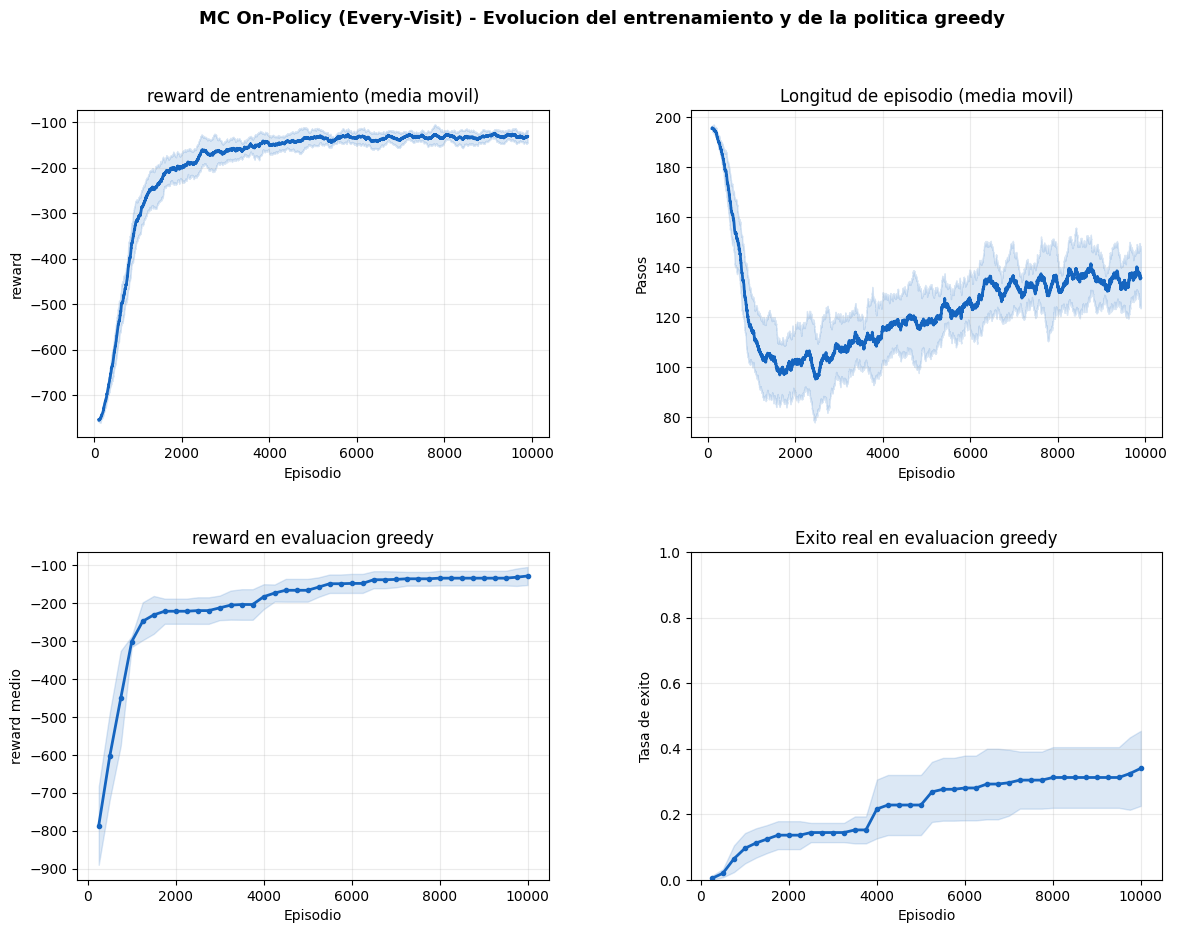

In [6]:
# Grafica la evolucion del metodo: entrenamiento (arriba) y evaluacion greedy (abajo).
plot_single_method(mc_on_results, "mc_on_policy")

In [7]:
# Imprime el reporte textual con metricas finales, brechas y convergencia por umbrales.
print_method_summary(mc_on_results, "mc_on_policy")

------------------------------------------------------------
  MC On-Policy (Every-Visit)
------------------------------------------------------------

Entrenamiento - ultimos 1000 episodios
  Reward         -130.918  +/-  10.162
  Longitud        134.791
  Exito real        37.5%

Evaluacion greedy final  (200 episodios x 5 semillas)
  Reward         -136.422  +/-  16.990
  Longitud        142.806  (penalizacion neta: +122.8 pasos)
  Exito real        30.4%

Curva de evaluacion greedy periodica  (primer -> ultimo punto)
  Episodio            250  ->  10,000
  Reward           -786.7  ->  -128.9
  Exito real         0.4%  ->  34.0%

Diagnostico comparativo
  Brecha exito train->greedy     +7.1 pp
  Reward greedy > 0            no alcanzado en el experimento

Convergencia greedy (primer episodio que supera umbral)
  >= 50% exito   no alcanzado
  >= 75% exito   no alcanzado
  >= 90% exito   no alcanzado
  >= 99% exito   no alcanzado
-------------------------------------------------------

#### Análisis de Resultados — MC On-Policy (Every-Visit)

**Desempeño final de la política greedy**  
El método cierra con reward medio de -136.422 ± 16.990, longitud media de 142.8 pasos y tasa de éxito de 30.4%. En términos operativos, la penalización neta de +122.8 pasos respecto al umbral de 20 supera ampliamente el bonus terminal de +20, por lo que el reward agregado permanece claramente negativo.

**Dinámica de aprendizaje observada en las curvas**  
En evaluación greedy periódica, el reward mejora de -786.7 (episodio 250) a -128.9 (episodio 10000), mientras que la tasa de éxito aumenta de 0.4% a 34.0%. Aun así, el reward no se vuelve positivo en ningún punto y el método no alcanza 50% de éxito, lo que indica una mejora monotónica pero insuficiente para converger a una política competitiva bajo el presupuesto de entrenamiento utilizado.

**Coherencia entre entrenamiento y evaluación**  
En los últimos 1000 episodios, el entrenamiento reporta reward de -130.918, longitud media de 134.791 y éxito de 37.5%, frente a 30.4% en evaluación greedy final. La brecha train-eval de 7.1 pp sugiere dependencia residual de la exploración `epsilon-greedy`.

**Lectura metodológica**  
El patrón es coherente con Monte Carlo every-visit: la señal de actualización se propaga al cierre de episodio, lo que retrasa la corrección de pares estado-acción relevantes en Taxi-v3. La desviación entre semillas del reward final (16.990) confirma alta sensibilidad a las trayectorias visitadas.

## 2. Monte Carlo off-policy con Weighted Importance Sampling

Aquí ya no se aprende sobre la misma política con la que se explora, a diferencia de On--policy.

- La política de comportamiento sigue siendo `epsilon-greedy` y es la que genera los episodios.
- La política objetivo es la política greedy respecto a `Q`.

La implementación es la siguiente:

1. Se genera un episodio completo con la política de comportamiento.
2. En cada paso se guarda también `b(a|s)`, es decir, la probabilidad real de la acción bajo esa política de comportamiento.
3. Al terminar el episodio se recorre la trayectoria hacia atrás.
4. Se acumula el retorno `G` y el peso de importancia `W`.
5. Se actualiza `Q` con `Weighted Importance Sampling`.
6. Si la acción observada deja de coincidir con la política greedy objetivo, el barrido se corta.

Guardar explícitamente `b(a|s)` era una corrección importante frente a implementaciones anteriores, porque evita reconstruir esa probabilidad a posteriori con una `Q` ya modificada.


In [8]:
# Entrena MC off-policy con Weighted IS y conserva resultados por semilla y agregados.
mc_off_results = run_method_experiment(config_obj, "mc_off_policy_weighted", verbose=True)

[run] MC Off-Policy (Weighted IS) | seed=123
[run] MC Off-Policy (Weighted IS) | seed=231
[run] MC Off-Policy (Weighted IS) | seed=777
[run] MC Off-Policy (Weighted IS) | seed=2024
[run] MC Off-Policy (Weighted IS) | seed=31415


In [9]:
# Resume el desempeño agregado de MC off-policy en una sola fila tabular.
method_summary_df(mc_off_results, "mc_off_policy_weighted")

,Entrenamiento reward ultimos 1000,Entrenamiento reward std entre semillas,Entrenamiento longitud ultimos 1000,Entrenamiento exito real ultimos 1000,Evaluacion greedy reward final,Evaluacion greedy reward std entre semillas,Evaluacion greedy longitud,Evaluacion greedy exito real
Metodo,,,,,,,,
MC Off-Policy (Weighted IS),-7.678,4.551,25.58,0.939,-4.953,5.543,23.154,0.952


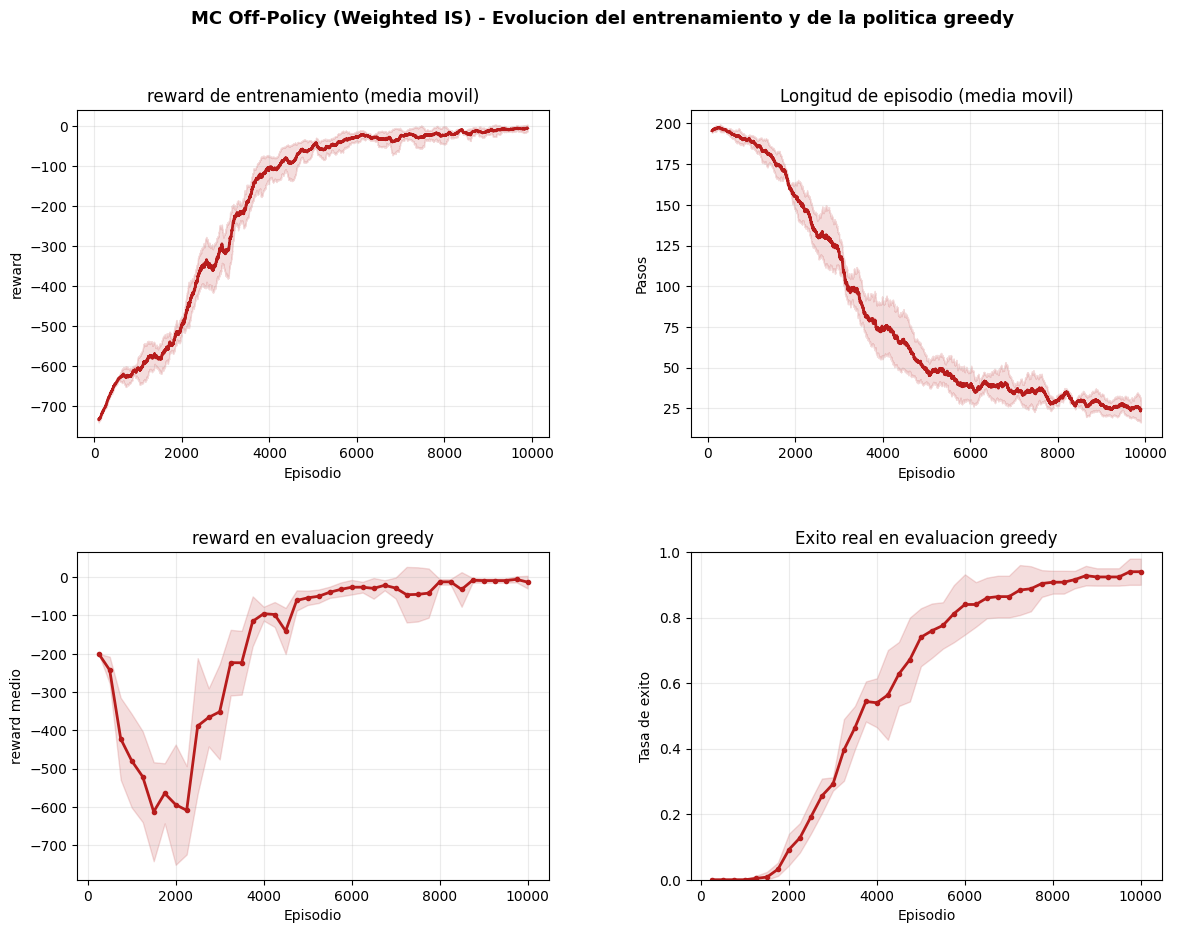

In [10]:
# Visualiza las curvas clave de MC off-policy para inspeccionar aprendizaje y estabilidad.
plot_single_method(mc_off_results, "mc_off_policy_weighted")

In [11]:
# Reporte textual detallado de MC off-policy con diagnostico train vs greedy.
print_method_summary(mc_off_results, "mc_off_policy_weighted")

------------------------------------------------------------
  MC Off-Policy (Weighted IS)
------------------------------------------------------------

Entrenamiento - ultimos 1000 episodios
  Reward           -7.678  +/-  4.551
  Longitud         25.580
  Exito real        93.9%

Evaluacion greedy final  (200 episodios x 5 semillas)
  Reward           -4.953  +/-  5.543
  Longitud         23.154  (penalizacion neta: +3.2 pasos)
  Exito real        95.2%

Curva de evaluacion greedy periodica  (primer -> ultimo punto)
  Episodio            250  ->  10,000
  Reward           -200.0  ->  -12.9
  Exito real         0.0%  ->  94.0%

Diagnostico comparativo
  Brecha exito train->greedy     -1.3 pp
  Reward greedy > 0            no alcanzado en el experimento

Convergencia greedy (primer episodio que supera umbral)
  >= 50% exito   episodio 3,750
  >= 75% exito   episodio 5,250
  >= 90% exito   episodio 7,750
  >= 99% exito   no alcanzado
-----------------------------------------------------

#### Análisis de Resultados — MC Off-Policy (Weighted Importance Sampling)

**Desempeño final de la política greedy**  
El método finaliza con reward de -4.953 ± 5.543, longitud media de 23.154 pasos y éxito real de 95.2%. Aunque el éxito es alto, la penalización neta de +3.2 pasos sobre el umbral de 20 mantiene el reward ligeramente negativo.

**Dinámica de aprendizaje observada en las curvas**  
En evaluación periódica, el reward evoluciona de -200.0 (episodio 250) a -12.9 (episodio 10000), mientras la tasa de éxito crece de 0.0% a 94.0%. El método alcanza 50%, 75% y 90% de éxito en los episodios 3750, 5250 y 7750, respectivamente, pero no llega a 99% dentro del horizonte evaluado.

**Coherencia entre entrenamiento y evaluación**  
En los últimos 1000 episodios de entrenamiento, registra reward de -7.678 ± 4.551, longitud de 25.580 y éxito de 93.9%. La brecha train-eval en éxito es de -1.3 pp, lo que indica buena correspondencia entre el comportamiento aprendido y la política greedy final.

**Lectura metodológica**  
Cuantitativamente, representa un avance claro respecto a MC on-policy, con alta capacidad de resolución de episodios. Sin embargo, la longitud final todavía no es suficientemente baja para sostener reward positivo en evaluación greedy.

## 3. SARSA tabular

SARSA es un método TD on-policy. A diferencia de Monte Carlo, no espera al final del episodio para corregir la tabla `Q`, sino que actualiza en cada transición usando la acción siguiente realmente elegida por la política actual.

Implementación en cada paso:

1. Se elige una acción `a` con la política `epsilon-greedy`.
2. Se observa `(s, a, r, s')`.
3. Si el episodio no ha terminado, se elige `a'` en `s'`.
4. Se aplica la actualización:

`Q(s,a) <- Q(s,a) + alpha * [r + gamma * Q(s',a') - Q(s,a)]`

Como es on-policy, la misma política que explora es la que se evalúa durante el aprendizaje.


In [12]:
# Entrena SARSA tabular bajo la misma configuracion para comparacion justa.
sarsa_results = run_method_experiment(config_obj, "sarsa", verbose=True)

[run] SARSA | seed=123
[run] SARSA | seed=231
[run] SARSA | seed=777
[run] SARSA | seed=2024
[run] SARSA | seed=31415


In [13]:
# Tabla de resumen de SARSA con metricas de entrenamiento y evaluacion final.
method_summary_df(sarsa_results, "sarsa")

,Entrenamiento reward ultimos 1000,Entrenamiento reward std entre semillas,Entrenamiento longitud ultimos 1000,Entrenamiento exito real ultimos 1000,Evaluacion greedy reward final,Evaluacion greedy reward std entre semillas,Evaluacion greedy longitud,Evaluacion greedy exito real
Metodo,,,,,,,,
SARSA,7.387,0.133,13.251,1.0,7.722,0.157,13.278,1.0


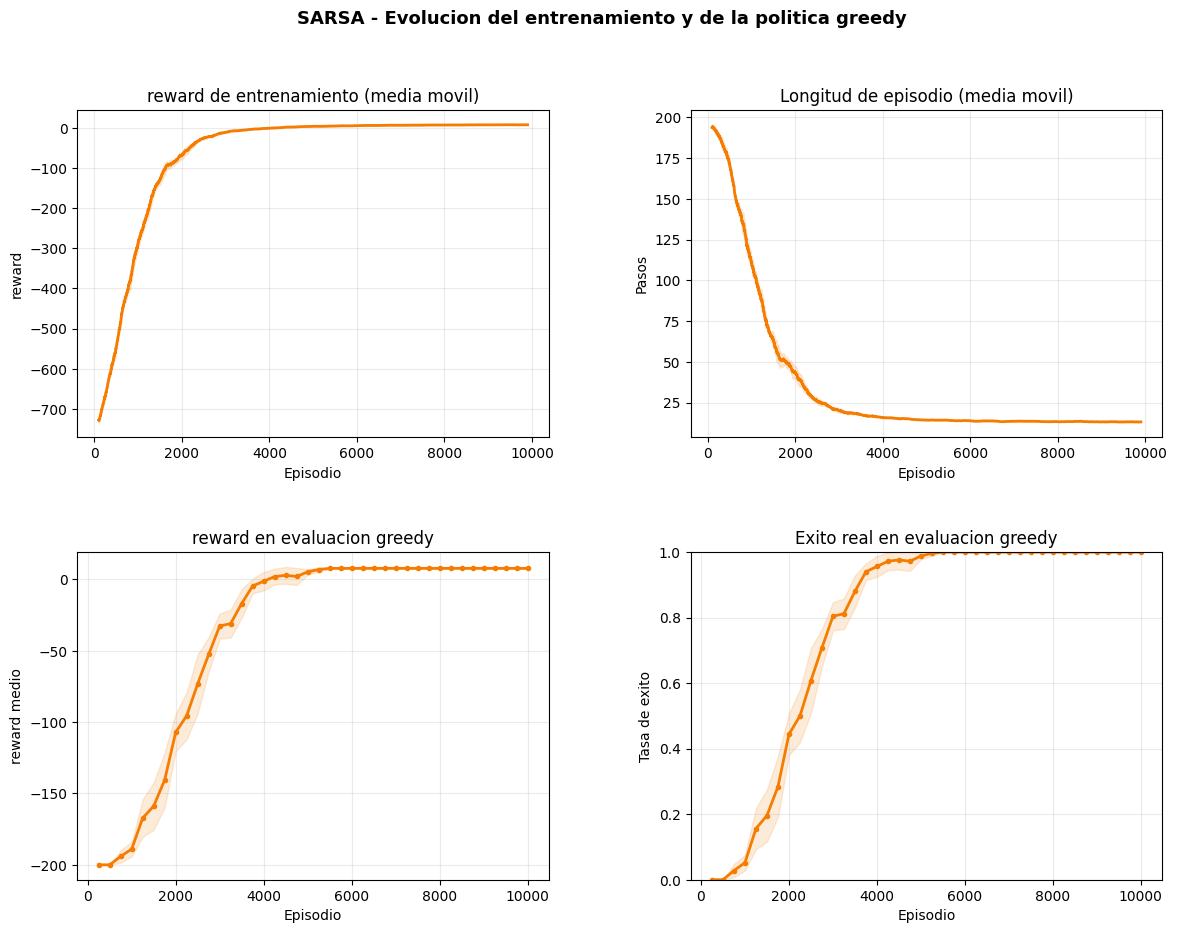

In [14]:
# Curvas de SARSA para revisar tendencia de reward, longitud y exito real.
plot_single_method(sarsa_results, "sarsa")

In [15]:
# Diagnostico textual de SARSA: desempeño final y episodios de convergencia.
print_method_summary(sarsa_results, "sarsa")

------------------------------------------------------------
  SARSA
------------------------------------------------------------

Entrenamiento - ultimos 1000 episodios
  Reward            7.387  +/-  0.133
  Longitud         13.251
  Exito real       100.0%

Evaluacion greedy final  (200 episodios x 5 semillas)
  Reward            7.722  +/-  0.157
  Longitud         13.278  (penalizacion neta: -6.7 pasos)
  Exito real       100.0%

Curva de evaluacion greedy periodica  (primer -> ultimo punto)
  Episodio            250  ->  10,000
  Reward           -200.0  ->  7.8
  Exito real         0.0%  ->  100.0%

Diagnostico comparativo
  Brecha exito train->greedy     +0.0 pp
  Reward greedy > 0            episodio 4,250

Convergencia greedy (primer episodio que supera umbral)
  >= 50% exito   episodio 2,250
  >= 75% exito   episodio 3,000
  >= 90% exito   episodio 3,750
  >= 99% exito   episodio 5,250
------------------------------------------------------------


#### Análisis de Resultados — SARSA (TD On-Policy)

**Desempeño final de la política greedy**  
SARSA obtiene reward final de 7.722 ± 0.157, longitud media de 13.278 pasos y éxito real de 100.0%. La diferencia de -6.7 pasos respecto al umbral de 20 confirma una política eficiente con reward positivo estable.

**Dinámica de aprendizaje observada en las curvas**  
La evaluación periódica transita de reward -200.0 (episodio 250) a 7.8 (episodio 10000), y de éxito 0.0% a 100.0%. El reward medio se vuelve positivo en el episodio 4250. La convergencia por umbrales ocurre en 2250 (50%), 3000 (75%), 3750 (90%) y 5250 (99%).

**Coherencia entre entrenamiento y evaluación**  
En los últimos 1000 episodios, el entrenamiento muestra reward de 7.387 ± 0.133, longitud de 13.251 y éxito de 100.0%. La brecha train-eval en éxito es 0.0 pp, lo que evidencia alineación alta entre desempeño durante entrenamiento y política greedy final.

**Lectura metodológica**  
El resultado describe convergencia robusta, baja variabilidad entre semillas y eficiencia temporal cercana al régimen óptimo del entorno, en línea con el comportamiento esperado de un método TD on-policy en Taxi-v3.

## 4. Q-Learning tabular

Q-Learning es off-policy. La política de comportamiento sigue siendo `epsilon-greedy`, pero la corrección TD usa el mejor valor estimado del siguiente estado, no la acción realmente muestreada.

La actualización es:

`Q(s,a) <- Q(s,a) + alpha * [r + gamma * max_a' Q(s',a') - Q(s,a)]`

En este tipo de problemas debería ser bueno porque:

- actualiza en cada paso
- propaga valores rápidamente
- y optimiza de forma más agresiva que SARSA


In [16]:
# Entrena Q-Learning tabular con los mismos hiperparametros y semillas.
q_learning_results = run_method_experiment(config_obj, "q_learning", verbose=True)

[run] Q-Learning | seed=123
[run] Q-Learning | seed=231
[run] Q-Learning | seed=777
[run] Q-Learning | seed=2024
[run] Q-Learning | seed=31415


In [17]:
# Tabla de resumen de Q-Learning para contraste directo con los otros metodos.
method_summary_df(q_learning_results, "q_learning")

,Entrenamiento reward ultimos 1000,Entrenamiento reward std entre semillas,Entrenamiento longitud ultimos 1000,Entrenamiento exito real ultimos 1000,Evaluacion greedy reward final,Evaluacion greedy reward std entre semillas,Evaluacion greedy longitud,Evaluacion greedy exito real
Metodo,,,,,,,,
Q-Learning,7.499,0.124,13.17,1.0,7.788,0.157,13.212,1.0


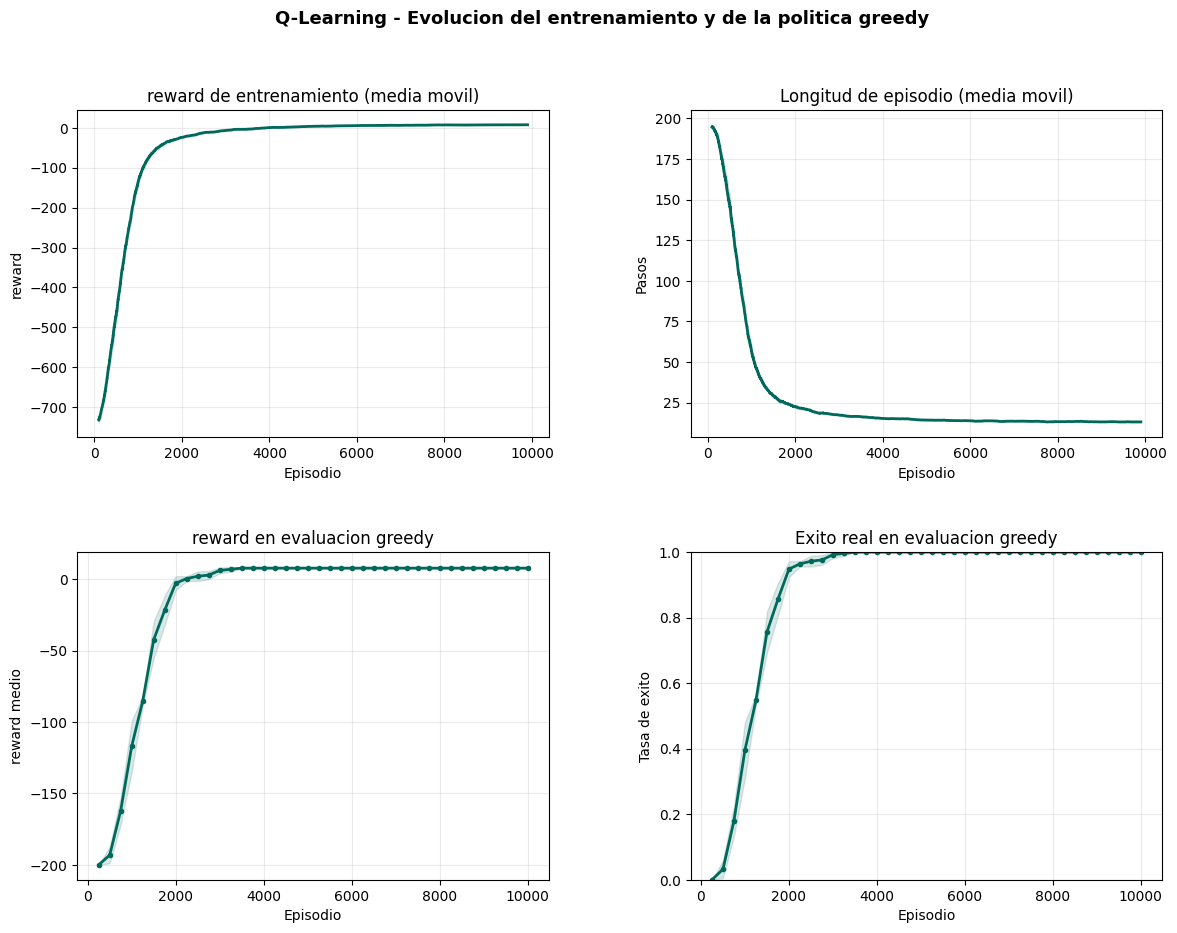

In [18]:
# Graficas de Q-Learning para observar velocidad de mejora y estabilidad entre semillas.
plot_single_method(q_learning_results, "q_learning")

In [19]:
# Reporte textual de Q-Learning con brechas train-greedy y umbrales de exito.
print_method_summary(q_learning_results, "q_learning")

------------------------------------------------------------
  Q-Learning
------------------------------------------------------------

Entrenamiento - ultimos 1000 episodios
  Reward            7.499  +/-  0.124
  Longitud         13.170
  Exito real       100.0%

Evaluacion greedy final  (200 episodios x 5 semillas)
  Reward            7.788  +/-  0.157
  Longitud         13.212  (penalizacion neta: -6.8 pasos)
  Exito real       100.0%

Curva de evaluacion greedy periodica  (primer -> ultimo punto)
  Episodio            250  ->  10,000
  Reward           -200.0  ->  7.8
  Exito real         0.0%  ->  100.0%

Diagnostico comparativo
  Brecha exito train->greedy     +0.0 pp
  Reward greedy > 0            episodio 2,250

Convergencia greedy (primer episodio que supera umbral)
  >= 50% exito   episodio 1,250
  >= 75% exito   episodio 1,500
  >= 90% exito   episodio 2,000
  >= 99% exito   episodio 3,000
------------------------------------------------------------


#### Análisis de Resultados — Q-Learning (TD Off-Policy)

**Desempeño final de la política greedy**  
Q-Learning alcanza reward final de 7.788 ± 0.157, longitud media de 13.212 pasos y éxito real de 100.0%. La diferencia de -6.8 pasos respecto al umbral de 20 confirma comportamiento eficiente y reward positivo sostenido.

**Dinámica de aprendizaje observada en las curvas**  
En evaluación periódica, el reward progresa de -200.0 (episodio 250) a 7.8 (episodio 10000), y la tasa de éxito de 0.0% a 100.0%. El reward medio se vuelve positivo en el episodio 2250, antes que en SARSA. La convergencia por umbrales ocurre en 1250 (50%), 1500 (75%), 2000 (90%) y 3000 (99%).

**Coherencia entre entrenamiento y evaluación**  
En los últimos 1000 episodios de entrenamiento, registra reward de 7.499 ± 0.124, longitud de 13.170 y éxito de 100.0%. La brecha train-eval en éxito es 0.0 pp, lo que respalda una correspondencia fuerte entre aprendizaje y desempeño final.

**Lectura metodológica**  
Los datos sitúan a Q-Learning como el método con convergencia más temprana, mejor reward final y baja variabilidad, manteniendo simultáneamente eficiencia de trayectoria y estabilidad inter-semillas.

## 5. Comparativa Global de algoritmos

Metodología comparativa seguida:

- Guardar el experimento completo
- Construir la tabla final agregada
- Dibujar las gráficas comparativas
- Analizar los resultados obtenidos


In [20]:
# Integra todos los metodos en una estructura comun para comparativa global.
all_results = combine_method_results(
    config_obj,
    {
        "mc_on_policy": mc_on_results,
        "mc_off_policy_weighted": mc_off_results,
        "sarsa": sarsa_results,
        "q_learning": q_learning_results,
    },
)

In [21]:
# Construye la tabla comparativa final ya ordenada por ranking de desempeño.
comparative_summary_df(all_results)

,Entrenamiento reward ultimos 1000,Entrenamiento longitud ultimos 1000,Entrenamiento exito real ultimos 1000,Evaluacion greedy reward final,Evaluacion greedy reward std entre semillas,Evaluacion greedy longitud,Evaluacion greedy exito real
Metodo,,,,,,,
Q-Learning,7.499,13.170,1.000,7.788,0.157,13.212,1.000
SARSA,7.387,13.251,1.000,7.722,0.157,13.278,1.000
MC Off-Policy (Weighted IS),-7.678,25.580,0.939,-4.953,5.543,23.154,0.952
MC On-Policy (Every-Visit),-130.918,134.791,0.375,-136.422,16.990,142.806,0.304


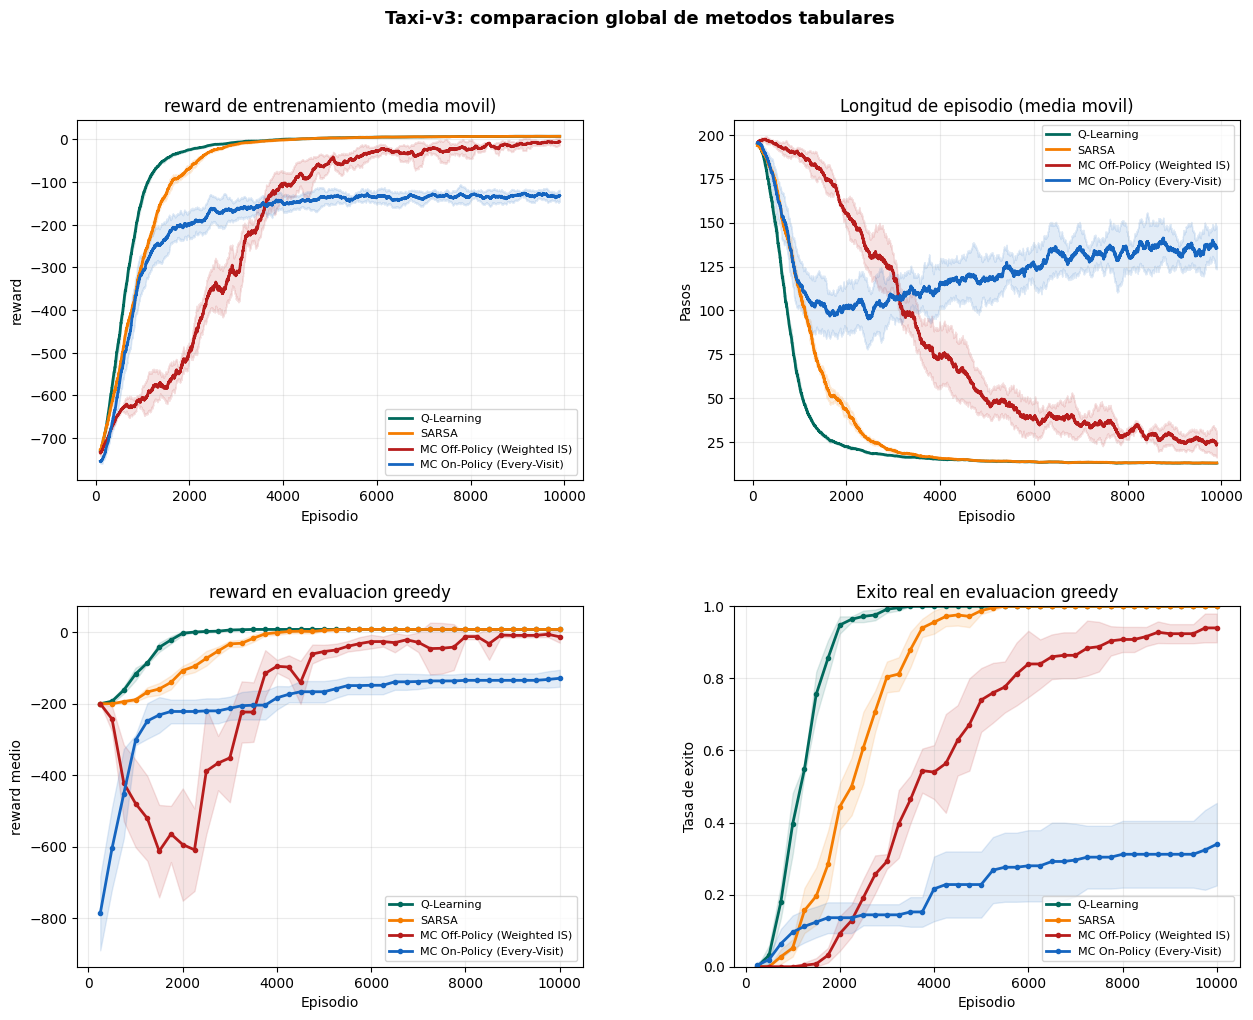

In [22]:
# Dibuja la comparacion multimetodo en entrenamiento y evaluacion greedy.
plot_comparative_results(all_results)

## Análisis Comparativo de Resultados

La evidencia conjunta de las pruebas realizadas persentan tres claros niveles de desempeño. En el nivel superior se ubican los métodos TD: Q-Learning (7.788 ± 0.157) y SARSA (7.722 ± 0.157), ambos con 100.0% de éxito greedy y longitudes medias de 13.212 y 13.278 pasos. En un nivel intermedio se sitúa MC Off-Policy (Weighted IS), con reward de -4.953 ± 5.543, éxito de 95.2% y longitud de 23.154 pasos. En el nivel inferior queda MC On-Policy (Every-Visit), con reward de -136.422 ± 16.990, éxito de 30.4% y longitud de 142.806 pasos.

En dinámica de aprendizaje, el gráfico confirma que Q-Learning y SARSA mejoran antes y con mayor pendiente que los enfoques Monte Carlo. Q-Learning cruza primero a reward positivo en el episodio 2250 y SARSA en el 4250, mientras que los dos métodos MC permanecen en reward negativo durante todo el horizonte. En convergencia por umbrales, Q-Learning también lidera (50%: 1250, 75%: 1500, 90%: 2000, 99%: 3000), seguido por SARSA (2250, 3000, 3750, 5250), MC Off-Policy (3750, 5250, 7750, sin alcanzar 99%) y MC On-Policy (sin alcanzar 50%).

Desde el punto de vista operativo, la longitud de episodio explica la diferencia entre éxito y reward en los métodos MC. MC Off-Policy alcanza alta tasa de éxito, pero su longitud media final (23.154) sigue por encima del umbral aproximado de 20 pasos necesario para sostener reward positivo esperado en Taxi-v3; por ello, su reward agregado se mantiene negativo. En contraste, Q-Learning y SARSA convergen a trayectorias cercanas a 13.2 pasos, compatibles con reward positivo estable.

En estabilidad, las desviaciones del reward final definen una jerarquía clara: TD (0.157) << MC Off-Policy (5.543) << MC On-Policy (16.990). Esta estructura coincide con el ancho de las bandas en el gráfico: estrechas y homogéneas en TD, intermedias en MC Off-Policy y marcadamente más amplias en MC On-Policy.

En síntesis, los datos muestran que, bajo este protocolo en Taxi-v3, los métodos TD dominan en velocidad de convergencia, calidad final de política y estabilidad entre semillas. Q-Learning conserva una ventaja final pequeña pero sistemática sobre SARSA en reward y rapidez de convergencia. MC Off-Policy mejora de forma importante frente a MC On-Policy, pero no alcanza el estándar de eficiencia temporal de los métodos TD.
